In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

### Logistic regression

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.8419


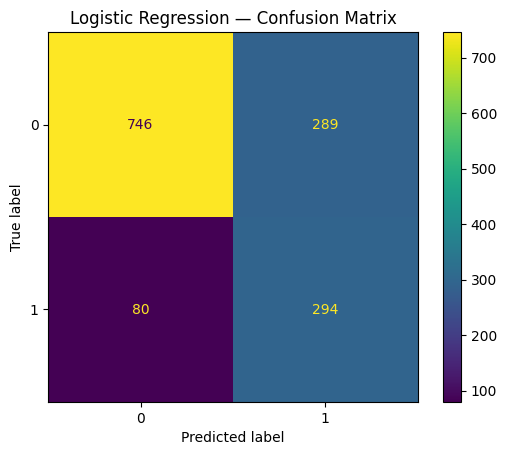

In [5]:
# Train
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

# Metrics
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.title('Logistic Regression — Confusion Matrix')
plt.show()

- High false positive due to class_weight='balanced', the model is agressive about spotting churn
- AUC score is more reliable due to an imbalanced data set
- Overall a solid baseline model

### Random Forest

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.61      0.49      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409

ROC-AUC: 0.8206


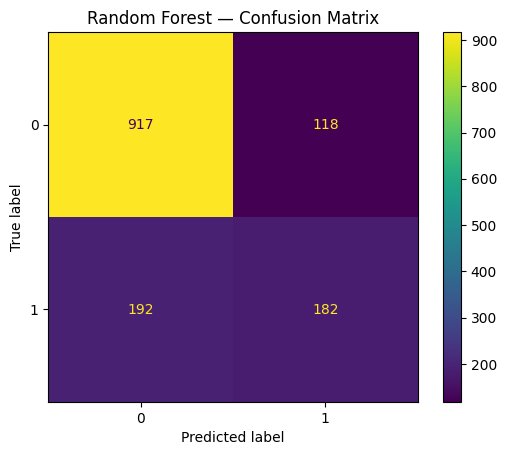

In [10]:
# Train
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1        # uses all CPU cores to train faster
)
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Metrics
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title('Random Forest — Confusion Matrix')
plt.show()

Logistic Regression with class_weight='balanced' aggressively overcompensates for the 27/73 imbalance, it lowers its decision threshold, casting a wide net to catch churners. It would rather flag 10 false alarms than miss one real churner. High recall, messy precision.

Random Forest with class_weight='balanced' handles imbalance differently. Each tree votes independently, and the majority vote naturally skews conservative, the forest needs reasonable consensus across trees before predicting churn. Stricter, fewer false alarms, but misses more real churners.

### XGBoost